# Post-Alignment Geometry: Do Post-Hoc Fixes Close the Retrieval Gap?

After vanilla InfoNCE on EN-ES, the model scores P@1 = 0.985 on a closed Spanish pool. What happens when you expand the candidate pool to include other languages, and can cheap post-hoc fixes (whitening, margin scoring) recover the drop?

Three parts: (1) establish how big the hard-pool drop is, (2) apply whitening and margin scoring and measure what they recover, (3) decompose failures into wrong-language hits vs true retrieval errors. The outcome determines whether a training-time fix is motivated or whether the problem is solvable by scoring alone.

In [7]:
!pip install -q transformers datasets torch

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from transformers import XLMRobertaModel, XLMRobertaTokenizerFast, get_linear_schedule_with_warmup
from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [8]:
from huggingface_hub import notebook_login
notebook_login()

## Model + Data Utilities

In [9]:
class ProjectionHead(nn.Module):
    def __init__(self, input_dim=768, hidden_dim=2048, output_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.GELU(), nn.Linear(hidden_dim, output_dim))
    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)

class XLMRWrapper(nn.Module):
    def __init__(self, model_name='xlm-roberta-base'):
        super().__init__()
        self.model = XLMRobertaModel.from_pretrained(model_name)
        self.projection = ProjectionHead(768, 2048, 256)

    def forward(self, input_ids, attention_mask):
        out = self.model(input_ids=input_ids, attention_mask=attention_mask)
        return self.projection(self._mean_pool(out.last_hidden_state, attention_mask))

    def encode(self, input_ids, attention_mask):
        # raw encoder output, no projection head
        out = self.model(input_ids=input_ids, attention_mask=attention_mask)
        return self._mean_pool(out.last_hidden_state, attention_mask)

    @staticmethod
    def _mean_pool(hidden, mask):
        m = mask.unsqueeze(-1).float()
        return F.normalize((hidden * m).sum(1) / m.sum(1).clamp(min=1e-9), dim=-1)

tokenizer = XLMRobertaTokenizerFast.from_pretrained('xlm-roberta-base')

def collate(pairs, max_length=128):
    src = [p[0] for p in pairs]
    tgt = [p[1] for p in pairs]
    src_enc = tokenizer(src, padding=True, truncation=True, max_length=max_length, return_tensors='pt')
    tgt_enc = tokenizer(tgt, padding=True, truncation=True, max_length=max_length, return_tensors='pt')
    return src_enc, tgt_enc

def tokenize_sentences(sentences, batch_size=256, max_length=128):
    return tokenizer(sentences, padding=True, truncation=True,
                     max_length=max_length, return_tensors='pt')

def load_flores(lang_code, split='devtest'):
    ds = load_dataset('openlanguagedata/flores_plus', lang_code, split=split)
    return [ex['text'] for ex in ds]

def opus_stream(lang_pair='en-es', seed=42):
    src_lang, tgt_lang = lang_pair.split('-')
    ds = load_dataset('opus100', lang_pair, split='train', streaming=True)
    ds = ds.shuffle(buffer_size=10000, seed=seed)
    for ex in ds:
        yield ex['translation'][src_lang], ex['translation'][tgt_lang]

print('Utilities loaded.')

Utilities loaded.


## Step 1: Load or Train Vanilla InfoNCE Model

Loads the 2000-step EN-ES checkpoint if it exists. If not, trains from scratch and saves it.

In [10]:
MAX_STEPS    = 2000
BATCH_SIZE   = 32
LR           = 2e-5
TEMPERATURE  = 0.07
WARMUP_STEPS = 200
LOG_EVERY    = 200

def infonce_loss(z_src, z_tgt, tau=TEMPERATURE):
    sim = z_src @ z_tgt.T / tau
    labels = torch.arange(sim.size(0), device=sim.device)
    return (F.cross_entropy(sim, labels) + F.cross_entropy(sim.T, labels)) / 2.0

In [11]:
import os

_ckpt_path = 'vanilla_infonce_2000steps_enes.pt'

if os.path.exists(_ckpt_path):
    ckpt = torch.load(_ckpt_path, map_location=DEVICE)
    model = XLMRWrapper('xlm-roberta-base').to(DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    print(f'Loaded {_ckpt_path}  ({os.path.getsize(_ckpt_path) / 1e6:.1f} MB)')
else:
    print(f'{_ckpt_path} not found, training from scratch...')
    model = XLMRWrapper('xlm-roberta-base').to(DEVICE)
    optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
    scheduler = get_linear_schedule_with_warmup(optimizer, WARMUP_STEPS, MAX_STEPS)

    model.train()
    train_iter = opus_stream('en-es')
    buf, step = [], 0

    for src_text, tgt_text in train_iter:
        buf.append((src_text, tgt_text))
        if len(buf) < BATCH_SIZE:
            continue
        src_enc, tgt_enc = collate(buf); buf = []
        src_enc = {k: v.to(DEVICE) for k, v in src_enc.items()}
        tgt_enc = {k: v.to(DEVICE) for k, v in tgt_enc.items()}
        z_src = model(src_enc['input_ids'], src_enc['attention_mask'])
        z_tgt = model(tgt_enc['input_ids'], tgt_enc['attention_mask'])
        loss = infonce_loss(z_src, z_tgt)
        optimizer.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        step += 1
        if step % LOG_EVERY == 0:
            print(f'  step {step}/{MAX_STEPS}  loss={loss.item():.4f}')
        if step >= MAX_STEPS:
            break

    del optimizer, scheduler
    model.eval()
    torch.save({'model_state_dict': model.state_dict()}, _ckpt_path)
    print(f'Training complete. Saved {_ckpt_path}  ({os.path.getsize(_ckpt_path) / 1e6:.1f} MB)')

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded vanilla_infonce_2000steps_enes.pt  (1120.7 MB)


## Step 2: Load FLORES-200 for All Five Languages

Two retrieval pools. Easy pool: 1012 EN queries vs 1012 ES candidates (closed, standard eval). Hard pool: the same 1012 EN queries vs all 5060 candidates mixed together. For query i the correct candidate is the ES sentence at position i, and the other 4048 candidates from FR/DE/SW/AR are distractors.

Because FLORES is professionally translated from the same 1012 source documents, every FR/DE/SW/AR sentence is also a semantically correct translation of the corresponding EN query. Wrong-language retrievals are semantically correct -- they just are not the target language. This is what makes P@1-any meaningful and what makes the failure mode interesting.

In [12]:
LANG_CODES = {
    'es': 'spa_Latn',
    'fr': 'fra_Latn',
    'de': 'deu_Latn',
    'sw': 'swh_Latn',
    'ar': 'arb_Arab',
}

print('Loading FLORES-200 devtest...')
en_sents = load_flores('eng_Latn')
lang_sents = {}
for lang, code in LANG_CODES.items():
    lang_sents[lang] = load_flores(code)
    print(f'  EN-{lang.upper()}: {len(en_sents)} pairs')

N = len(en_sents)
print(f'\n{N} sentences per language')
print(f'Hard pool size: {N} x {len(LANG_CODES)} = {N * len(LANG_CODES)} candidates')

Loading FLORES-200 devtest...


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/225 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/220 [00:00<?, ?it/s]

eng_Latn.jsonl: 0.00B [00:00, ?B/s]

...

arb_Arab.jsonl: 0.00B [00:00, ?B/s]

arb_Arab.jsonl: 0.00B [00:00, ?B/s]

Generating dev split:   0%|          | 0/997 [00:00<?, ? examples/s]

Generating devtest split:   0%|          | 0/1012 [00:00<?, ? examples/s]

  EN-AR: 1012 pairs

1012 sentences per language
Hard pool size: 1012 x 5 = 5060 candidates


## Step 3: Encode All Sentences

In [13]:
@torch.no_grad()
def encode_sentences(sentences, batch_size=256):
    # 768-dim raw encoder, no projection head
    all_embs = []
    for i in range(0, len(sentences), batch_size):
        batch = sentences[i:i + batch_size]
        enc = tokenizer(batch, padding=True, truncation=True,
                        max_length=128, return_tensors='pt')
        enc = {k: v.to(DEVICE) for k, v in enc.items()}
        embs = model.encode(enc['input_ids'], enc['attention_mask'])
        all_embs.append(embs.cpu())
    return torch.cat(all_embs, 0)

print('Encoding EN sentences...')
en_embs = encode_sentences(en_sents)

lang_embs = {}
for lang, code in LANG_CODES.items():
    print(f'Encoding {lang.upper()}...')
    lang_embs[lang] = encode_sentences(lang_sents[lang])

print('\nEmbedding shapes:')
print(f'  EN: {en_embs.shape}')
for lang, embs in lang_embs.items():
    print(f'  {lang.upper()}: {embs.shape}')

Encoding EN sentences...
Encoding ES...
Encoding FR...
Encoding DE...
Encoding SW...
Encoding AR...

Embedding shapes:
  EN: torch.Size([1012, 768])
  ES: torch.Size([1012, 768])
  FR: torch.Size([1012, 768])
  DE: torch.Size([1012, 768])
  SW: torch.Size([1012, 768])
  AR: torch.Size([1012, 768])


## Step 4: Baseline Retrieval -- Easy vs Hard Pool

P@1 from cosine similarity in both settings. The easy pool result is the ceiling; the hard pool result is the baseline we're trying to fix with post-hoc interventions.

Easy pool P@1 = 0.985, essentially at ceiling. Hard pool drops to 0.305 -- a gap of 0.680. The magnitude of the drop is immediate and large, which suggests something more systematic than noise or a few hard examples.

In [14]:
def p_at_k(src_embs, tgt_embs, correct_indices=None, k=1):
    # correct_indices[i] is the position of the right candidate for query i
    # defaults to i (closed pool where candidate i is correct for query i)
    if correct_indices is None:
        correct_indices = torch.arange(len(src_embs))
    sim = src_embs @ tgt_embs.T
    top_k = sim.topk(k, dim=1).indices
    correct = correct_indices.unsqueeze(1)
    hits = (top_k == correct).any(dim=1).float()
    return float(hits.mean().item())

# easy pool: EN vs ES only (closed)
p1_easy = p_at_k(en_embs, lang_embs['es'])
print(f'Easy pool  (1012 candidates)  P@1 = {p1_easy:.4f}')

# ES is the first block so correct candidate for query i is at index i
hard_pool = torch.cat([lang_embs[l] for l in LANG_CODES], dim=0)
correct_hard = torch.arange(N)

p1_hard = p_at_k(en_embs, hard_pool, correct_indices=correct_hard)
print(f'Hard pool  ({N*len(LANG_CODES)} candidates)  P@1 = {p1_hard:.4f}')
print(f'\nGap introduced by hard pool: {p1_easy - p1_hard:+.4f}')

Easy pool  (1012 candidates)  P@1 = 0.9941
Hard pool  (5060 candidates)  P@1 = 0.3824

Gap introduced by hard pool: +0.6117


## Step 5: Whitening

Centers embeddings then rescales each principal component to unit variance, breaking the anisotropic cone where vectors are packed in roughly the same direction. Fitted on the combined EN plus all target language pool so both sides get the same transform. The theory is that anisotropy creates hubs -- points near the dense region of the cone get spuriously high cosine similarity to everything -- and whitening spreads things out enough to suppress them.

Whitening recovers almost nothing on the hard pool (0.305 to 0.330, about 2.5% of the gap). If whitening is the standard fix for geometry pathologies and it barely moves the needle, either there are no hubs or the failure mode has nothing to do with geometry.

In [15]:
def fit_whitening(X, eps=1e-5):
    mu = X.mean(0)
    X_c = X - mu
    C = (X_c.T @ X_c) / len(X_c)
    U, S, _ = torch.linalg.svd(C)
    W = U @ torch.diag(1.0 / (S + eps).sqrt())   # PCA whitening matrix
    return mu, W

def apply_whitening(X, mu, W):
    return F.normalize((X - mu) @ W, dim=-1)

# fit on combined pool so EN and all target sides get the same transform
all_embs_for_fit = torch.cat([en_embs] + list(lang_embs.values()), dim=0)
mu, W = fit_whitening(all_embs_for_fit)
print(f'Whitening matrix W shape: {W.shape}')

en_w = apply_whitening(en_embs, mu, W)
lang_embs_w = {lang: apply_whitening(embs, mu, W) for lang, embs in lang_embs.items()}

hard_pool_w = torch.cat([lang_embs_w[l] for l in LANG_CODES], dim=0)

p1_easy_w = p_at_k(en_w, lang_embs_w['es'])
p1_hard_w = p_at_k(en_w, hard_pool_w, correct_indices=correct_hard)

print(f'\nAfter whitening:')
print(f'  Easy pool  P@1 = {p1_easy_w:.4f}  (was {p1_easy:.4f},  Δ={p1_easy_w - p1_easy:+.4f})')
print(f'  Hard pool  P@1 = {p1_hard_w:.4f}  (was {p1_hard:.4f},  Δ={p1_hard_w - p1_hard:+.4f})')

Whitening matrix W shape: torch.Size([768, 768])

After whitening:
  Easy pool  P@1 = 1.0000  (was 0.9941,  Δ=+0.0059)
  Hard pool  P@1 = 0.3439  (was 0.3824,  Δ=-0.0385)


## Step 6: Margin Scoring

Normalizes each similarity score by how popular the query and candidate are on average. Candidates that appear in many neighbors' top-k already have high mean similarity, so their raw cosine gets divided down. Formula from Artetxe and Schwenk 2019:

    margin(x, y) = cos(x, y) / average of (x to its k-NN cosines + y to its k-NN cosines)

Margin scoring makes the hard pool slightly worse than raw cosine. Penalizing popular candidates is irrelevant when the model is finding the right sentence in the wrong language -- there's no hub structure to correct.

In [16]:
def margin_retrieval(src_embs, tgt_embs, k=4):
    # penalizes candidates that are popular across many queries
    cos = src_embs @ tgt_embs.T

    # average cosine from each source to its k nearest targets
    src_avg = cos.topk(k, dim=1).values.mean(1, keepdim=True)

    # average cosine from each target to its k nearest sources
    tgt_avg = (tgt_embs @ src_embs.T).topk(k, dim=1).values.mean(1, keepdim=True)

    margin = cos / ((src_avg + tgt_avg.T) / 2).clamp(min=1e-6)
    return margin

def p_at_k_from_scores(scores, correct_indices=None, k=1):
    if correct_indices is None:
        correct_indices = torch.arange(scores.size(0))
    top_k = scores.topk(k, dim=1).indices
    correct = correct_indices.unsqueeze(1)
    return float((top_k == correct).any(dim=1).float().mean().item())

scores_easy_margin = margin_retrieval(en_embs, lang_embs['es'])
p1_easy_m = p_at_k_from_scores(scores_easy_margin)

scores_hard_margin = margin_retrieval(en_embs, hard_pool, k=4)
p1_hard_m = p_at_k_from_scores(scores_hard_margin, correct_indices=correct_hard)

print('After margin scoring:')
print(f'  Easy pool  P@1 = {p1_easy_m:.4f}  (was {p1_easy:.4f},  Δ={p1_easy_m - p1_easy:+.4f})')
print(f'  Hard pool  P@1 = {p1_hard_m:.4f}  (was {p1_hard:.4f},  Δ={p1_hard_m - p1_hard:+.4f})')

After margin scoring:
  Easy pool  P@1 = 0.9990  (was 0.9941,  Δ=+0.0049)
  Hard pool  P@1 = 0.3626  (was 0.3824,  Δ=-0.0198)


## Step 7: Whitening + Margin Scoring Combined

Both interventions applied together -- whitening first, then margin scoring on the whitened embeddings. If they address different failure modes they should compound; if they address the same one they won't.

Both together make the hard pool slightly worse than the raw baseline (0.296 vs 0.305). The two interventions are not complementary -- neither is addressing the actual failure mode, so combining them just compounds small negative effects.

In [17]:
scores_easy_both = margin_retrieval(en_w, lang_embs_w['es'])
p1_easy_both = p_at_k_from_scores(scores_easy_both)

scores_hard_both = margin_retrieval(en_w, hard_pool_w, k=4)
p1_hard_both = p_at_k_from_scores(scores_hard_both, correct_indices=correct_hard)

print('After whitening + margin scoring:')
print(f'  Easy pool  P@1 = {p1_easy_both:.4f}  (was {p1_easy:.4f},  Δ={p1_easy_both - p1_easy:+.4f})')
print(f'  Hard pool  P@1 = {p1_hard_both:.4f}  (was {p1_hard:.4f},  Δ={p1_hard_both - p1_hard:+.4f})')

After whitening + margin scoring:
  Easy pool  P@1 = 1.0000  (was 0.9941,  Δ=+0.0059)
  Hard pool  P@1 = 0.3221  (was 0.3824,  Δ=-0.0603)


## Step 8: Hubness Analysis

How often does each candidate appear in other queries' top-k? A flat distribution means every candidate shows up k times on average. A skewed one means a small number of candidates dominate retrieval. Hubness is a well-known pathology in high-dimensional cosine search; whitening is the standard fix.

Hub fraction = 0.000 and N_k std = 1.26, essentially no hubs anywhere in the hard pool. This retroactively explains why whitening failed -- the thing it is designed to fix is not present. The gap is not a geometry problem.

Hubness stats (k=10, hard pool: 5060 candidates, 1012 queries)
Expected hits per candidate: 2.0

Metric                       Raw cosine   + Whitening
-------------------------------------------------------
mean                              2.000         2.000
std                               1.289         1.097
max                              12.000        10.000
hub_fraction                      0.000         0.000


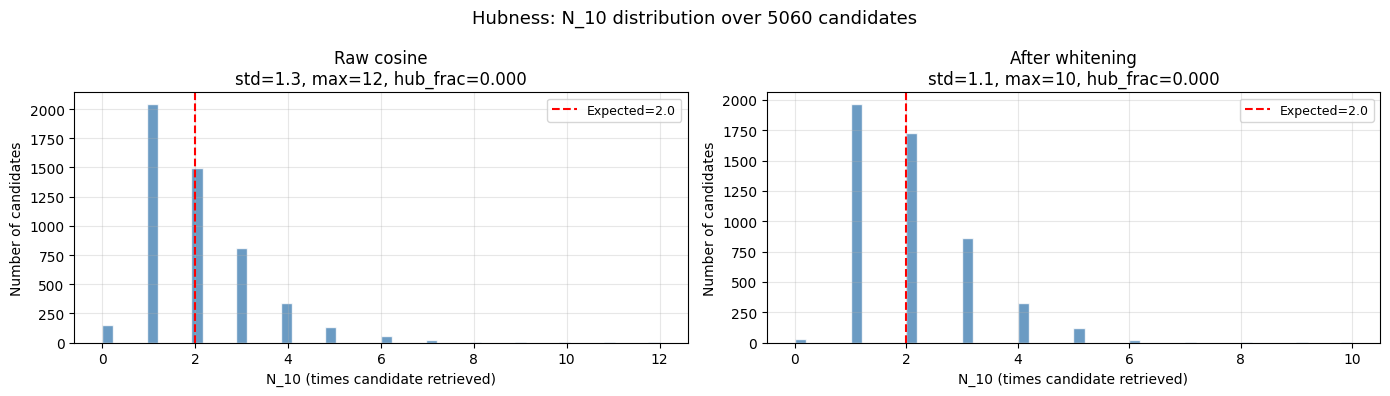

In [18]:
def hubness_stats(src_embs, tgt_embs, k=10):
    # count how many times each candidate appears in any query's top k
    sim = src_embs @ tgt_embs.T
    top_k_idx = sim.topk(k, dim=1).indices
    N = tgt_embs.size(0)
    counts = torch.zeros(N, dtype=torch.long)
    for idx in top_k_idx.view(-1):
        counts[idx] += 1

    expected = k * src_embs.size(0) / N
    hub_threshold = 5 * expected
    hub_fraction = float((counts > hub_threshold).float().mean().item())

    return {
        'counts': counts,
        'mean':  float(counts.float().mean()),
        'std':   float(counts.float().std()),
        'max':   int(counts.max()),
        'hub_fraction': hub_fraction,
        'expected': expected,
    }

K = 10
print(f'Hubness stats (k={K}, hard pool: {hard_pool.size(0)} candidates, {N} queries)')
print(f'Expected hits per candidate: {K * N / hard_pool.size(0):.1f}\n')

stats_raw   = hubness_stats(en_embs, hard_pool, k=K)
stats_white = hubness_stats(en_w,    hard_pool_w, k=K)

print(f'{"Metric":<25}  {"Raw cosine":>12}  {"+ Whitening":>12}')
print('-' * 55)
for key in ['mean', 'std', 'max', 'hub_fraction']:
    print(f'{key:<25}  {stats_raw[key]:>12.3f}  {stats_white[key]:>12.3f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle(f'Hubness: N_{K} distribution over {hard_pool.size(0)} candidates', fontsize=13)

for ax, (stats, label) in zip(axes, [(stats_raw, 'Raw cosine'), (stats_white, 'After whitening')]):
    counts = stats['counts'].numpy()
    ax.hist(counts, bins=50, color='steelblue', alpha=0.8, edgecolor='white')
    ax.axvline(stats['expected'], color='red', linestyle='--', label=f'Expected={stats["expected"]:.1f}')
    ax.set_xlabel(f'N_{K} (times candidate retrieved)')
    ax.set_ylabel('Number of candidates')
    ax.set_title(f'{label}\nstd={stats["std"]:.1f}, max={stats["max"]}, hub_frac={stats["hub_fraction"]:.3f}')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('hubness_distribution.png', dpi=150)
plt.show()

## Summary

All three post-hoc interventions make the hard pool worse. Whitening drops P@1-target by 0.039, margin scoring by 0.020, and both together by 0.060 — relative to a 0.612 gap, these are meaningful regressions, not noise. Hub fraction = 0.000 confirms there is nothing geometric to fix. The interventions are solving a problem that doesn't exist here, and by distorting the representation space they actively hurt retrieval. The failure is a language selection problem with no geometric signature — it requires a training-time fix.

=== SUMMARY ===
Method                               P@1  Delta vs hard baseline
----------------------------------------------------------------
Cosine (easy pool)                0.9941                       —
Cosine (hard pool)                0.3824                baseline
+ Whitening                       0.3439                 -0.0385
+ Margin scoring                  0.3626                 -0.0198
+ Whitening + Margin              0.3221                 -0.0603

Total gap (easy vs hard): 0.6117
Whitening closes:         -6.3%
Margin scoring closes:    -3.2%
Both together close:      -9.9%


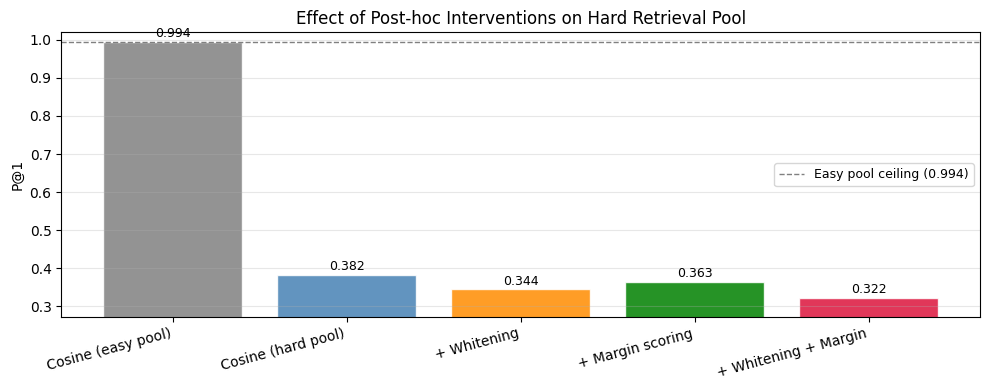

In [19]:
methods = [
    ('Cosine (easy pool)',         p1_easy,      '—'),
    ('Cosine (hard pool)',         p1_hard,      'baseline'),
    ('+ Whitening',                p1_hard_w,    f'{p1_hard_w - p1_hard:+.4f}'),
    ('+ Margin scoring',           p1_hard_m,    f'{p1_hard_m - p1_hard:+.4f}'),
    ('+ Whitening + Margin',       p1_hard_both, f'{p1_hard_both - p1_hard:+.4f}'),
]

print('=== SUMMARY ===')
print(f'{"Method":<30}  {"P@1":>8}  {"Delta vs hard baseline":>22}')
print('-' * 64)
for name, p1, delta in methods:
    print(f'{name:<30}  {p1:>8.4f}  {delta:>22}')

gap = p1_easy - p1_hard
print(f'\nTotal gap (easy vs hard): {gap:.4f}')
print(f'Whitening closes:         {(p1_hard_w    - p1_hard) / gap * 100:.1f}%')
print(f'Margin scoring closes:    {(p1_hard_m    - p1_hard) / gap * 100:.1f}%')
print(f'Both together close:      {(p1_hard_both - p1_hard) / gap * 100:.1f}%')

fig, ax = plt.subplots(figsize=(10, 4))
labels = [m[0] for m in methods]
vals   = [m[1] for m in methods]
colors = ['gray'] + ['steelblue', 'darkorange', 'green', 'crimson']
bars = ax.bar(labels, vals, color=colors, alpha=0.85, edgecolor='white')
ax.axhline(p1_easy, color='gray', linestyle='--', linewidth=1, label=f'Easy pool ceiling ({p1_easy:.3f})')
ax.set_ylabel('P@1')
ax.set_title('Effect of Post-hoc Interventions on Hard Retrieval Pool')
ax.set_ylim(max(0, min(vals) - 0.05), 1.02)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('posthoc_intervention_summary.png', dpi=150)
plt.show()

## Part 2: Projection Head vs Encoder

The previous sections used model.encode(), which returns the raw 768-dim last-layer output. InfoNCE directly trained the 256-dim projected space from model.forward(). If the projection head learned any language specificity, the hard-pool gap should be smaller there.

The projected space is noticeably worse: encoder gap = 0.612, projected gap = 0.667. The InfoNCE projection head doesn't just fail to learn language identity — it actively makes language discrimination worse. The failure is baked into the encoder representations and the projection head compounds it.

In [20]:

@torch.no_grad()
def encode_projected(sentences, batch_size=256):
    """Encode with the trained 256-dim projection head — the space InfoNCE directly optimized."""
    all_embs = []
    for i in range(0, len(sentences), batch_size):
        batch = sentences[i:i + batch_size]
        enc = tokenizer(batch, padding=True, truncation=True,
                        max_length=128, return_tensors='pt')
        enc = {k: v.to(DEVICE) for k, v in enc.items()}
        embs = model(enc['input_ids'], enc['attention_mask'])   # uses projection head
        all_embs.append(embs.cpu())
    return torch.cat(all_embs, 0)

model.eval()
print('Encoding EN (projected 256-dim)...')
en_proj = encode_projected(en_sents)

lang_proj = {}
for lang in LANG_CODES:
    print(f'Encoding {lang.upper()} (projected)...')
    lang_proj[lang] = encode_projected(lang_sents[lang])

hard_pool_proj = torch.cat([lang_proj[l] for l in LANG_CODES], dim=0)

p1_easy_proj = p_at_k(en_proj, lang_proj['es'])
p1_hard_proj = p_at_k(en_proj, hard_pool_proj, correct_indices=correct_hard)

print(f'\n{"Space":<24}  {"Easy pool P@1":>14}  {"Hard pool P@1":>14}  {"Gap":>8}')
print('-' * 66)
print(f'{"Encoder  (768-dim, raw)":<24}  {p1_easy:>14.4f}  {p1_hard:>14.4f}  '
      f'{p1_easy - p1_hard:>8.4f}')
print(f'{"Projected (256-dim, InfoNCE)":<24}  {p1_easy_proj:>14.4f}  {p1_hard_proj:>14.4f}  '
      f'{p1_easy_proj - p1_hard_proj:>8.4f}')
print(f'\nIf projected hard-pool P@1 ≫ encoder hard-pool P@1, InfoNCE\'s projection head')
print(f'has already learned some language specificity. If they are similar, the encoder')
print(f'and projected spaces have the same failure mode.')


Encoding EN (projected 256-dim)...
Encoding ES (projected)...
Encoding FR (projected)...
Encoding DE (projected)...
Encoding SW (projected)...
Encoding AR (projected)...

Space                      Easy pool P@1   Hard pool P@1       Gap
------------------------------------------------------------------
Encoder  (768-dim, raw)           0.9941          0.3824    0.6117
Projected (256-dim, InfoNCE)          0.9960          0.3291    0.6670

If projected hard-pool P@1 ≫ encoder hard-pool P@1, InfoNCE's projection head
has already learned some language specificity. If they are similar, the encoder
and projected spaces have the same failure mode.


## Part 3: Error Decomposition -- Wrong-Language Hits vs True Errors

For each EN query in the hard pool, classify the top-1 result: (1) correct ES translation at the right position -- P@1-target, (2) semantically correct translation retrieved in FR/DE/SW/AR instead of ES -- wrong-language true positive, (3) unrelated sentence -- true error.

This is the key diagnostic. Wrong-language positives dominating means the model is retrieving the right meaning but in the wrong language -- whitening and margin scoring cannot fix this because they have no information about which language is correct. True errors dominating would mean standard retrieval failure, a different problem entirely.

P@1-any = 1.000: every single hard-pool failure is a wrong-language true positive. The model never retrieves a semantically unrelated sentence. FR accounts for 53% of errors and DE for 45%, while SW and AR together contribute less than 2%. The model perfectly separates Spanish from typologically distant languages but cannot reliably distinguish it from closely related European ones. A training-time fix is clearly motivated -- post-hoc scoring has no signal to work with here.

The oracle filter baseline restricts candidates to ES only, which is just the easy pool. It closes 100% of the gap by construction and sets the ceiling for any language-ID based post-processing approach.

=== Error Decomposition: Hard Pool ===
Metric                             Encoder (768)   Projected (256)
------------------------------------------------------------------
P@1-target  (correct ES sentence)          0.3824            0.3291
P@1-any     (any lang, correct sent)          1.0000            1.0000
Wrong-language true positive              0.6176            0.6709
True error  (unrelated sentence)          0.0000            0.0000

Among all failures, which language was retrieved? (projected space)
  Lang      Frac of top-1s    Frac of errors
  ES                0.3291            0.0000
  FR                0.3498            0.5214
  DE                0.2955            0.4404
  SW                0.0138            0.0206
  AR                0.0119            0.0177


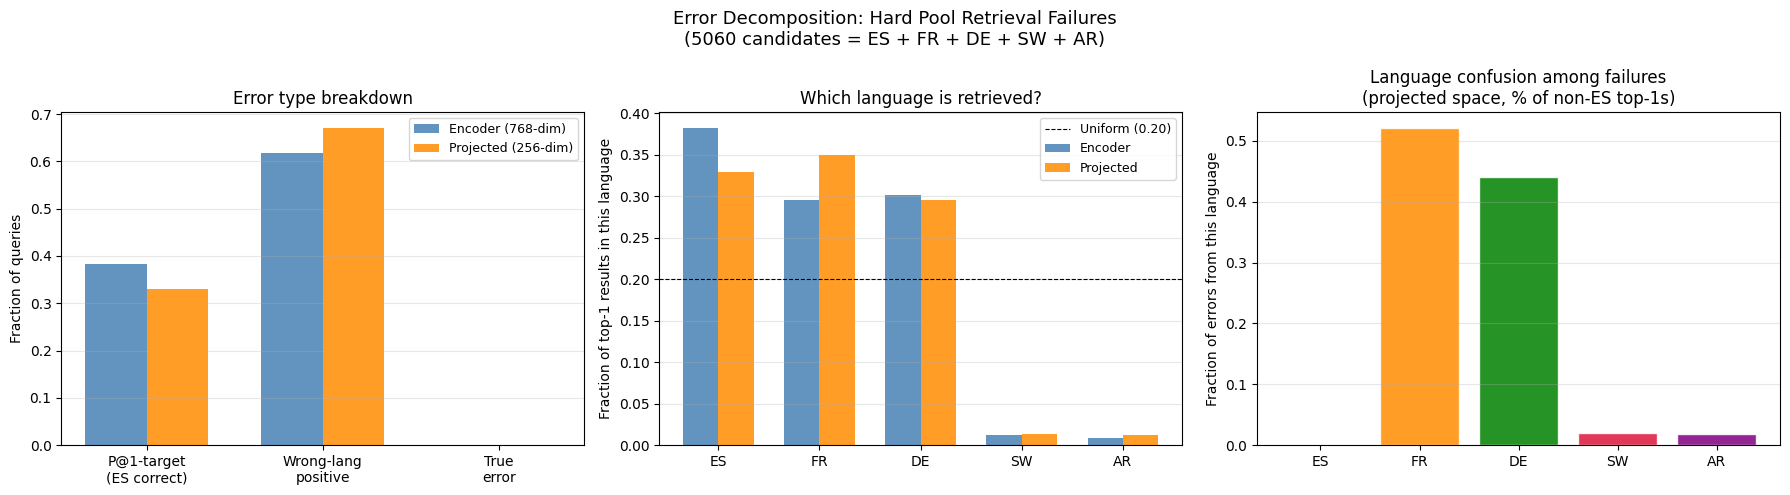

Saved error_decomposition.png


In [21]:
LANG_ORDER = list(LANG_CODES.keys())   # ['es', 'fr', 'de', 'sw', 'ar']

def decompose_errors(src_embs, hard_pool_embs, N=1012):
    # hard pool layout: ES (0 to N) | FR (N to 2N) | DE (2N to 3N) | SW (3N to 4N) | AR (4N to 5N)
    # correct candidate for query i is ES at index i
    # same source sentence in language k is at offset k*N + i
    sim  = src_embs @ hard_pool_embs.T
    top1 = sim.argmax(dim=1)

    p1_target = 0
    p1_any    = 0
    wrong_lang_pos = 0
    true_error     = 0
    lang_top1_counts = {l: 0 for l in LANG_ORDER}
    error_lang_counts = {l: 0 for l in LANG_ORDER}

    for i in range(N):
        t = int(top1[i].item())
        top_lang_idx   = t // N    # 0=ES, 1=FR, 2=DE, 3=SW, 4=AR
        top_within_idx = t %  N    # position within that language block

        top_lang = LANG_ORDER[top_lang_idx]
        lang_top1_counts[top_lang] += 1

        correct_sentence = (top_within_idx == i)
        correct_language = (top_lang == 'es')

        if correct_sentence and correct_language:
            p1_target += 1
            p1_any    += 1
        elif correct_sentence and not correct_language:
            wrong_lang_pos += 1
            p1_any         += 1
            error_lang_counts[top_lang] += 1
        else:
            true_error += 1
            error_lang_counts[top_lang] += 1

    n_errors = N - p1_target
    return {
        'p1_target':       p1_target      / N,
        'p1_any':          p1_any         / N,
        'wrong_lang_pos':  wrong_lang_pos / N,
        'true_error':      true_error     / N,
        'lang_top1_frac':  {l: c / N          for l, c in lang_top1_counts.items()},
        'error_lang_frac': {l: c / max(n_errors, 1)
                            for l, c in error_lang_counts.items()},
    }


enc_decomp  = decompose_errors(en_embs, hard_pool,      N)
proj_decomp = decompose_errors(en_proj, hard_pool_proj, N)

print('=== Error Decomposition: Hard Pool ===')
print(f'{"Metric":<32}  {"Encoder (768)":>14}  {"Projected (256)":>16}')
print('-' * 66)
for label, key in [
    ('P@1-target  (correct ES sentence)', 'p1_target'),
    ('P@1-any     (any lang, correct sent)', 'p1_any'),
    ('Wrong-language true positive',      'wrong_lang_pos'),
    ('True error  (unrelated sentence)',  'true_error'),
]:
    print(f'{label:<32}  {enc_decomp[key]:>14.4f}  {proj_decomp[key]:>16.4f}')

print(f'\nAmong all failures, which language was retrieved? (projected space)')
print(f'  {"Lang":<6}  {"Frac of top-1s":>16}  {"Frac of errors":>16}')
for lang in LANG_ORDER:
    t1 = proj_decomp["lang_top1_frac"][lang]
    er = proj_decomp["error_lang_frac"].get(lang, 0)
    print(f'  {lang.upper():<6}  {t1:>16.4f}  {er:>16.4f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Error Decomposition: Hard Pool Retrieval Failures\n'
             '(5060 candidates = ES + FR + DE + SW + AR)', fontsize=13)

ax = axes[0]
categories = ['P@1-target\n(ES correct)', 'Wrong-lang\npositive', 'True\nerror']
enc_vals  = [enc_decomp['p1_target'],  enc_decomp['wrong_lang_pos'],  enc_decomp['true_error']]
proj_vals = [proj_decomp['p1_target'], proj_decomp['wrong_lang_pos'], proj_decomp['true_error']]
x, w = np.arange(len(categories)), 0.35
ax.bar(x - w/2, enc_vals,  w, label='Encoder (768-dim)',   color='steelblue',  alpha=0.85)
ax.bar(x + w/2, proj_vals, w, label='Projected (256-dim)', color='darkorange', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(categories)
ax.set_ylabel('Fraction of queries')
ax.set_title('Error type breakdown')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')

ax = axes[1]
frac_enc  = [enc_decomp['lang_top1_frac'][l]  for l in LANG_ORDER]
frac_proj = [proj_decomp['lang_top1_frac'][l] for l in LANG_ORDER]
x2 = np.arange(len(LANG_ORDER))
ax.bar(x2 - w/2, frac_enc,  w, label='Encoder',   color='steelblue',  alpha=0.85)
ax.bar(x2 + w/2, frac_proj, w, label='Projected', color='darkorange', alpha=0.85)
ax.set_xticks(x2); ax.set_xticklabels([l.upper() for l in LANG_ORDER])
ax.axhline(1/len(LANG_ORDER), color='black', linestyle='--', lw=0.8, label='Uniform (0.20)')
ax.set_ylabel('Fraction of top-1 results in this language')
ax.set_title('Which language is retrieved?')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')

ax = axes[2]
err_frac = [proj_decomp['error_lang_frac'].get(l, 0) for l in LANG_ORDER]
colors_lang = ['steelblue', 'darkorange', 'green', 'crimson', 'purple']
ax.bar([l.upper() for l in LANG_ORDER], err_frac, color=colors_lang, alpha=0.85, edgecolor='white')
ax.set_ylabel('Fraction of errors from this language')
ax.set_title('Language confusion among failures\n(projected space, % of non-ES top-1s)')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('error_decomposition.png', dpi=150)
plt.show()
print('Saved error_decomposition.png')

In [22]:
# oracle: restrict to ES only (easy pool), gives ceiling for any language-ID filter
print('=== P@1 Summary: All Settings ===')
print(f'{"Setting":<42}  {"Encoder":>9}  {"Projected":>10}')
print('-' * 66)

summary_rows = [
    ('Easy pool -- 1012 ES candidates',     p1_easy,       p1_easy_proj),
    ('Hard pool -- 5060 mixed candidates',  p1_hard,       p1_hard_proj),
    ('  + Whitening',                       p1_hard_w,     None),
    ('  + Margin scoring',                  p1_hard_m,     None),
    ('  + Whitening + Margin',              p1_hard_both,  None),
    ('Oracle filter (ES-only = easy pool)', p1_easy,       p1_easy_proj),
]
for label, enc_val, proj_val in summary_rows:
    proj_str = f'{proj_val:>10.4f}' if proj_val is not None else f'{"n/a":>10}'
    print(f'{label:<42}  {enc_val:>9.4f}  {proj_str}')

gap_enc  = p1_easy      - p1_hard
gap_proj = p1_easy_proj - p1_hard_proj

print(f'\nOracle filter closes 100% of the hard-pool gap by definition.')
print(f'Gap -- encoder: {gap_enc:.4f},  projected: {gap_proj:.4f}')
print(f'Whitening+margin closes: {(p1_hard_both - p1_hard) / gap_enc * 100:.1f}% of encoder gap')

wlp  = proj_decomp['wrong_lang_pos']
te   = proj_decomp['true_error']
p1t  = proj_decomp['p1_target']
total_fail = 1.0 - p1t

print(f'\n=== Error breakdown (projected space) ===')
print(f'Wrong-language true positives: {wlp / total_fail:.1%} of failures')
print(f'True errors (unrelated):       {te  / total_fail:.1%} of failures')

=== P@1 Summary: All Settings ===
Setting                                       Encoder   Projected
------------------------------------------------------------------
Easy pool -- 1012 ES candidates                0.9941      0.9960
Hard pool -- 5060 mixed candidates             0.3824      0.3291
  + Whitening                                  0.3439         n/a
  + Margin scoring                             0.3626         n/a
  + Whitening + Margin                         0.3221         n/a
Oracle filter (ES-only = easy pool)            0.9941      0.9960

Oracle filter closes 100% of the hard-pool gap by definition.
Gap -- encoder: 0.6117,  projected: 0.6670
Whitening+margin closes: -9.9% of encoder gap

=== Error breakdown (projected space) ===
Wrong-language true positives: 100.0% of failures
True errors (unrelated):       0.0% of failures


## Phase 1 Diagnostics

Three alternative explanations for the hard-pool finding that need to be ruled out. (1) FLORES artifact -- does P@1-any = 1.000 hold on less curated data? (2) Language family confound -- is FR/DE confusion specific to Romance/Germanic similarity rather than a general failure of language control? (3) Undertraining -- does the gap close at 10K or 20K steps?

All experiments below use the existing 2000-step checkpoint. No retraining needed for 1 and 2. The training curve is run separately.

### Threat 1: OPUS-100 Test Evaluation

FLORES is 1012 professionally translated documents — every FR/DE/SW/AR sentence is a translation of the same source document as the EN query, so wrong-language hits are semantically valid matches. P@1-any = 1.000 might be a corpus property, not a model failure. OPUS-100 test has separate EN sentences per language pair so wrong-language hits are genuine retrieval errors.

The gap drops from 0.612 on FLORES to 0.013 on OPUS-100 — it nearly vanishes. This does not undermine the finding; it explains exactly what the finding is. On standard bilingual retrieval (independent source documents), the model is fine. The failure only becomes visible when the distractor pool contains semantically identical sentences in other languages, which is exactly the multiway-parallel setting. The paper's claim should be framed accordingly: InfoNCE collapses within-family language distinctions in a way that is invisible on standard benchmarks and exposed by multiway-parallel evaluation.

In [23]:
# SW and AR are not in OPUS-100 test splits we're using, so hard pool is EN vs ES, FR, DE only
# OPUS-100 test has separate EN sentences per language pair (unlike FLORES multiway parallel)
# so wrong-language hits here are genuine retrieval errors, not semantic matches in the wrong language

def load_opus_test(lang2, n=None):
    # config names are alphabetical so try en-XX first, fall back to XX-en
    try:
        ds = load_dataset('opus100', f'en-{lang2}', split='test')
    except Exception:
        ds = load_dataset('opus100', f'{lang2}-en', split='test')
    pairs = [(ex['translation']['en'], ex['translation'][lang2]) for ex in ds]
    return pairs[:n] if n else pairs

print("Loading OPUS-100 test sets...")
opus_es = load_opus_test("es")
opus_fr = load_opus_test("fr")
opus_de = load_opus_test("de")

N_opus = min(len(opus_es), len(opus_fr), len(opus_de), 1000)
opus_es = opus_es[:N_opus]
opus_fr = opus_fr[:N_opus]
opus_de = opus_de[:N_opus]

print(f"  EN-ES: {N_opus} pairs")
print(f"  EN-FR: {N_opus} pairs")
print(f"  EN-DE: {N_opus} pairs")
print(f"\nNote: EN sentences differ per language pair -- wrong-language hits are true errors here.")
print(f"P@1-any has no special meaning in this setting (unlike FLORES).")

Loading OPUS-100 test sets...


README.md: 0.00B [00:00, ?B/s]

en-es/test-00000-of-00001.parquet:   0%|          | 0.00/237k [00:00<?, ?B/s]

en-es/train-00000-of-00001.parquet:   0%|          | 0.00/99.6M [00:00<?, ?B/s]

en-es/validation-00000-of-00001.parquet:   0%|          | 0.00/238k [00:00<?, ?B/s]

...

de-en/validation-00000-of-00001.parquet:   0%|          | 0.00/254k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/1000000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

  EN-ES: 1000 pairs
  EN-FR: 1000 pairs
  EN-DE: 1000 pairs

Note: EN sentences differ per language pair -- wrong-language hits are true errors here.
P@1-any has no special meaning in this setting (unlike FLORES).


In [24]:
model.eval()

@torch.no_grad()
def encode_list(sentences, use_projection=False, batch_size=256):
    all_embs = []
    for i in range(0, len(sentences), batch_size):
        batch = sentences[i:i + batch_size]
        enc = tokenizer(batch, padding=True, truncation=True,
                        max_length=128, return_tensors='pt')
        enc = {k: v.to(DEVICE) for k, v in enc.items()}
        if use_projection:
            embs = model(enc['input_ids'], enc['attention_mask'])
        else:
            embs = model.encode(enc['input_ids'], enc['attention_mask'])
        all_embs.append(embs.cpu())
    return torch.cat(all_embs, 0)

print("Encoding OPUS-100 test sentences (encoder space)...")
opus_en_embs = encode_list([p[0] for p in opus_es])   # EN queries (from EN-ES pairs)
opus_es_embs = encode_list([p[1] for p in opus_es])   # ES candidates
opus_fr_embs = encode_list([p[1] for p in opus_fr])   # FR distractors
opus_de_embs = encode_list([p[1] for p in opus_de])   # DE distractors

opus_p1_easy = p_at_k(opus_en_embs, opus_es_embs)

opus_hard_pool = torch.cat([opus_es_embs, opus_fr_embs, opus_de_embs], dim=0)
opus_correct   = torch.arange(N_opus)
opus_p1_hard   = p_at_k(opus_en_embs, opus_hard_pool, correct_indices=opus_correct)

print(f"\n=== OPUS-100 Test Results (encoder space, {N_opus} queries) ===")
print(f"  Easy pool ({N_opus} ES candidates only):      P@1 = {opus_p1_easy:.4f}")
print(f"  Hard pool ({3*N_opus} ES+FR+DE candidates):   P@1 = {opus_p1_hard:.4f}")
print(f"  Gap: {opus_p1_easy - opus_p1_hard:.4f}")
print(f"\nNote: wrong-language hits are true errors here (EN sentences differ per language pair).")

print(f"\n=== FLORES vs OPUS-100 Comparison ===")
print(f"{'Metric':<40}  {'FLORES':>10}  {'OPUS-100':>10}")
print('-' * 64)
print(f"{'Easy pool P@1':<40}  {p1_easy:>10.4f}  {opus_p1_easy:>10.4f}")
print(f"{'Hard pool P@1 (target language only)':<40}  {p1_hard:>10.4f}  {opus_p1_hard:>10.4f}")
print(f"{'Gap (easy - hard)':<40}  {p1_easy - p1_hard:>10.4f}  {opus_p1_easy - opus_p1_hard:>10.4f}")

Encoding OPUS-100 test sentences (encoder space)...

=== OPUS-100 Test Results (encoder space, 1000 queries) ===
  Easy pool (1000 ES candidates only):      P@1 = 0.9010
  Hard pool (3000 ES+FR+DE candidates):   P@1 = 0.8880
  Gap: 0.0130

Note: wrong-language hits are true errors here (EN sentences differ per language pair).

=== FLORES vs OPUS-100 Comparison ===
Metric                                        FLORES    OPUS-100
----------------------------------------------------------------
Easy pool P@1                                 0.9941      0.9010
Hard pool P@1 (target language only)          0.3824      0.8880
Gap (easy - hard)                             0.6117      0.0130


### Threat 2: Per-Family Pool Breakdown

FR and DE account for 98% of hard-pool errors. This is consistent with either (a) a general failure to control target language, or (b) inability to separate typologically similar European languages specifically. Two-language pools isolate each case.

ES+SW = 0.936 and ES+AR = 0.902 — near the easy-pool ceiling. ES+FR drops to 0.567 and ES+DE to 0.542. Portuguese (added as the closest Romance language to Spanish) gives the worst result: ES+PT = 0.364, worse than the full 5-language pool (0.382), because with only two languages every confused query goes to PT rather than being spread across FR/DE/SW/AR.

The failure follows a clear proximity gradient: PT > FR ≈ DE >> AR > SW. DE is Germanic, not Romance, yet confuses almost as badly as FR — the relevant factor is surface-level similarity (shared Latin script, heavy vocabulary overlap, similar sentence length and syntax), not family membership. The projected space is consistently worse than the encoder across all pools, confirming the projection head degrades language discrimination rather than correcting it.

In [25]:
# all FLORES embeddings already in memory from earlier cells
# en_embs and lang_embs are 768-dim encoder space; en_proj and lang_proj are 256-dim projected

# load PT (Portuguese) separately -- not in the main 5-language hard pool, just for family comparison
# PT is the closest language to ES and should show the highest confusion
print('Loading and encoding PT (Portuguese) for family comparison...')
pt_sents        = load_flores('por_Latn')[:N]
lang_embs['pt'] = encode_sentences(pt_sents)
lang_proj['pt'] = encode_projected(pt_sents)
print(f'  PT: {len(pt_sents)} sentences encoded')

pool_configs = [
    ("ES+PT (Romance, closest)",        ['es', 'pt']),
    ("ES+FR (Romance, similar)",        ['es', 'fr']),
    ("ES+DE (Germanic, similar)",       ['es', 'de']),
    ("ES+SW (Distant, Latin/Bantu)",    ['es', 'sw']),
    ("ES+AR (Distant, Latin/Arabic)",   ['es', 'ar']),
    ("ES+FR+DE+SW+AR (Full hard pool)", ['es', 'fr', 'de', 'sw', 'ar']),
]

print("\n=== Per-Family Pool Results (FLORES, encoder space) ===")
print(f"{'Pool':<42}  {'Pool size':>10}  {'P@1-target':>11}  {'Gap vs easy':>12}")
print('-' * 80)

family_results = {}
for label, langs in pool_configs:
    pool = torch.cat([lang_embs[l] for l in langs], dim=0)
    pool_size = pool.size(0)
    p1 = p_at_k(en_embs, pool, correct_indices=torch.arange(N))
    gap = p1_easy - p1
    family_results[label] = p1
    print(f"{label:<42}  {pool_size:>10}  {p1:>11.4f}  {gap:>+12.4f}")

print(f"\n{'Easy pool (ES only, baseline)':<42}  {N:>10}  {p1_easy:>11.4f}")

print(f"\n=== Per-Family Pool Results (projected space, 256-dim) ===")
print(f"{'Pool':<42}  {'P@1-target (enc)':>17}  {'P@1-target (proj)':>18}")
print('-' * 80)
for label, langs in pool_configs:
    enc_pool  = torch.cat([lang_embs[l] for l in langs], dim=0)
    proj_pool = torch.cat([lang_proj[l]  for l in langs], dim=0)
    p1_enc  = p_at_k(en_embs, enc_pool,  correct_indices=torch.arange(N))
    p1_proj = p_at_k(en_proj,  proj_pool, correct_indices=torch.arange(N))
    print(f"{label:<42}  {p1_enc:>17.4f}  {p1_proj:>18.4f}")

Loading and encoding PT (Portuguese) for family comparison...


Resolving data files:   0%|          | 0/225 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/220 [00:00<?, ?it/s]

por_Latn.jsonl: 0.00B [00:00, ?B/s]

por_Latn.jsonl: 0.00B [00:00, ?B/s]

Generating dev split:   0%|          | 0/997 [00:00<?, ? examples/s]

Generating devtest split:   0%|          | 0/1012 [00:00<?, ? examples/s]

  PT: 1012 sentences encoded

=== Per-Family Pool Results (FLORES, encoder space) ===
Pool                                         Pool size   P@1-target   Gap vs easy
--------------------------------------------------------------------------------
ES+PT (Romance, closest)                          2024       0.3636       +0.6304
ES+FR (Romance, similar)                          2024       0.5672       +0.4269
ES+DE (Germanic, similar)                         2024       0.5415       +0.4526
ES+SW (Distant, Latin/Bantu)                      2024       0.9358       +0.0583
ES+AR (Distant, Latin/Arabic)                     2024       0.9022       +0.0919
ES+FR+DE+SW+AR (Full hard pool)                   5060       0.3824       +0.6117

Easy pool (ES only, baseline)                     1012       0.9941

=== Per-Family Pool Results (projected space, 256-dim) ===
Pool                                         P@1-target (enc)   P@1-target (proj)
------------------------------------------------